## 📂 Load Dataset 

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Step 1: Create the data generators
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Step 2: Load images using those generators
train_data = train_datagen.flow_from_directory(
    r'C:\Users\rajve\OneDrive\Desktop\all_programs\jupyter programs\Brain tumor prediction project\Training',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    r'C:\Users\rajve\OneDrive\Desktop\all_programs\jupyter programs\Brain tumor prediction project\Testing',
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)


Found 5712 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


## 💌 Read DataSet

In [4]:
import os
from sklearn.utils import shuffle

# Local system paths instead of Colab paths
train_dir = r'C:\Users\rajve\OneDrive\Desktop\all_programs\jupyter programs\Brain tumor prediction project\Training'
test_dir = r'C:\Users\rajve\OneDrive\Desktop\all_programs\jupyter programs\Brain tumor prediction project\Testing'

# Initialize lists
train_paths = []
train_labels = []

# Read and collect image paths and labels
for label in os.listdir(train_dir):
    label_folder = os.path.join(train_dir, label)
    if os.path.isdir(label_folder):
        for image in os.listdir(label_folder):
            train_paths.append(os.path.join(label_folder, image))
            train_labels.append(label)

# Shuffle the data
train_paths, train_labels = shuffle(train_paths, train_labels)

# Optional check
print(f"Total training images: {len(train_paths)}")
print(f"Example: {train_paths[0]}  -->  Label: {train_labels[0]}")

#time for testing
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
    label_folder = os.path.join(test_dir, label)
    if os.path.isdir(label_folder):
        for image in os.listdir(label_folder):
            test_paths.append(os.path.join(label_folder, image))
            test_labels.append(label)

# Shuffle the data
test_paths, test_labels = shuffle(test_paths, test_labels)

# Optional check
print(f"Total training images: {len(test_paths)}")
print(f"Example: {test_paths[0]}  -->  Label: {test_labels[0]}")

Total training images: 5712
Example: C:\Users\rajve\OneDrive\Desktop\all_programs\jupyter programs\Brain tumor prediction project\Training\notumor\Tr-no_1313.jpg  -->  Label: notumor
Total training images: 1311
Example: C:\Users\rajve\OneDrive\Desktop\all_programs\jupyter programs\Brain tumor prediction project\Testing\glioma\Te-gl_0225.jpg  -->  Label: glioma


## 📦 Imports Libraries and Tools

In [5]:
import os  #for directory and file operations
import numpy as np  #for numerical operations and handling image arrays
import random  #for generating random values for augmentation
from PIL import Image, ImageEnhance  #for image processing and enhancement
import matplotlib.pyplot as plt

# keras
from tensorflow.keras.models import Sequential  #for building the model
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout  #for model layers
from tensorflow.keras.preprocessing.image import load_img  #for loading images
from tensorflow.keras.optimizers import Adam  #for optimizer
from tensorflow.keras.applications import VGG16  #for using VGG16 model
from sklearn.utils import shuffle  #for shuffling the data

## 📊 Data Visualization

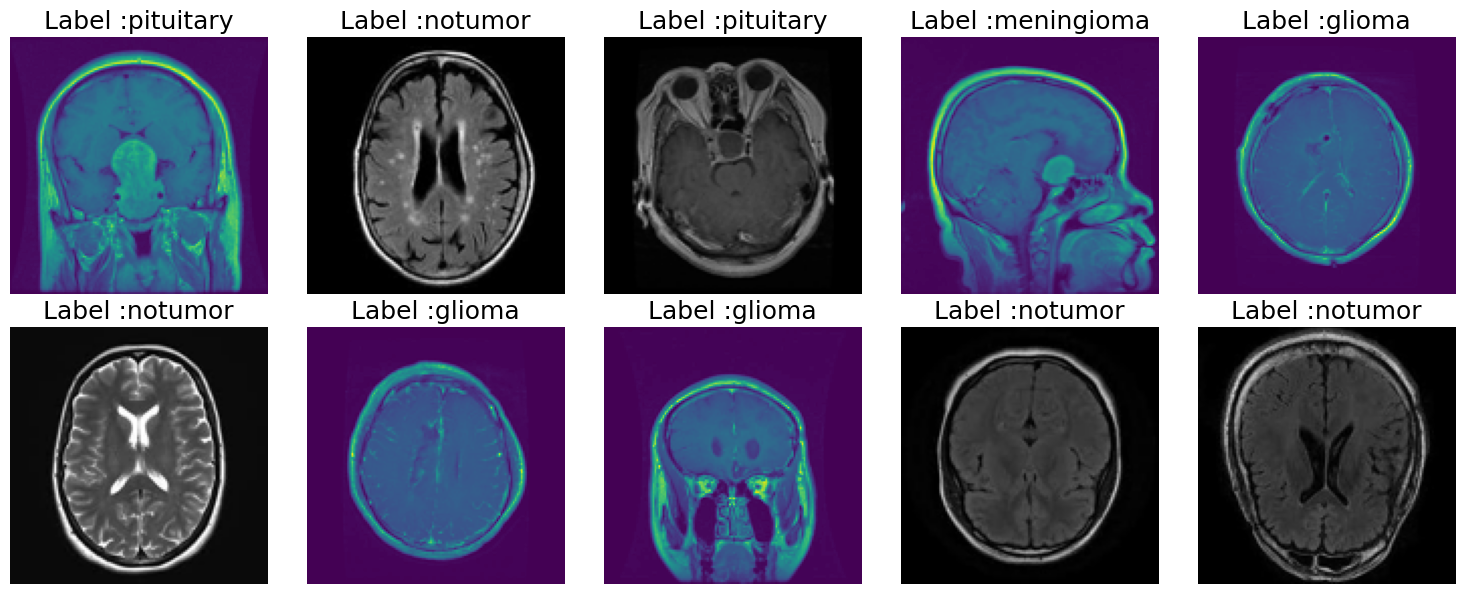

In [6]:
import random
import matplotlib.pyplot as plt

#Select random indices for 10 images
random_indices = random.sample(range(len(train_paths)),10)

#Create a figure to display images in 2 rows
fig, axes = plt.subplots(2, 5, figsize=(15,6))
axes=axes.ravel()

# Loop through the random indices and display images
for i, idx in enumerate(random_indices):
    img_path = train_paths[idx]
    img = Image.open(img_path)
    img = img.resize((128,128))

    #Display Images
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Label :{train_labels[idx]}", fontsize=18)
plt.tight_layout()
plt.show()


## 🎥 Image Preprocessing

In [7]:
# Image Augmentation Function
def augment_image(image): 
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))
    image = np.array(image) / 255.0
    return image

# Load images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoder labels (Convert label names to integers)
def encode_label(labels):
    unique_labels = os.listdir(train_dir) # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Dat generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths) # Open and augment images
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels) # Encode labels
            yield batch_images, batch_labels # Yield the batch
            

## Just Testing


In [7]:
import tensorflow as tf

if tf.config.list_physical_devices('GPU'):
    print("✅ GPU is available!")
else:
    print("⚠️  GPU not available. Training will run on CPU.")

✅ GPU is available!


## Model Architechture


In [40]:
from tensorflow.keras.models import Sequential
# Model Architechture (128,128,3)
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE,IMAGE_SIZE, 3), include_top=False, weights='imagenet')

# Freeze all layers of the VGG16 model
for layers in base_model.layers:
    layers.trainable = False

# Set only the last few layers
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build Final Model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE,IMAGE_SIZE,3))) #Input layer
model.add(base_model) # VGG16 model
model.add(Flatten()) # Flatten layer
model.add(Dropout(0.3)) # Dropout layer (drop randomly 30 neurons)

model.add(Dense(128, activation='relu')) # Dense layer
model.add(Dropout(0.2)) # Dropout layer

model.add(Dense(len(os.listdir(train_dir)),activation='softmax')) # Output Layer

# Compile Model
model.compile(optimizer=Adam(learning_rate=0.0001),loss='sparse_categorical_crossentropy',metrics=['sparse_categorical_accuracy'])

# Parameters
batch_size = 20
steps = int(len(train_paths) / batch_size) #Steps per epoch
epochs = 15

# train model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
    epochs=epochs, steps_per_epoch=steps)

Epoch 1/15
285/285 [==============================] - 59s 181ms/step - loss: 0.4484 - sparse_categorical_accuracy: 0.8312
Epoch 2/15
285/285 [==============================] - 34s 114ms/step - loss: 0.2259 - sparse_categorical_accuracy: 0.9136
Epoch 3/15
285/285 [==============================] - 30s 104ms/step - loss: 0.1663 - sparse_categorical_accuracy: 0.9406
Epoch 4/15
285/285 [==============================] - 39s 136ms/step - loss: 0.1012 - sparse_categorical_accuracy: 0.9626
Epoch 5/15
285/285 [==============================] - 38s 134ms/step - loss: 0.0836 - sparse_categorical_accuracy: 0.9701
Epoch 6/15
285/285 [==============================] - 41s 145ms/step - loss: 0.0770 - sparse_categorical_accuracy: 0.9719
Epoch 7/15
285/285 [==============================] - 43s 150ms/step - loss: 0.0567 - sparse_categorical_accuracy: 0.9805
Epoch 8/15
285/285 [==============================] - 41s 146ms/step - loss: 0.0491 - sparse_categorical_accuracy: 0.9817
Epoch 9/15
285/285 [====

## Model Saving and History saving (for plotting)

In [41]:
'''
model.save(r"C:\Users\rajve\OneDrive\Desktop\all_programs\jupyter programs\Brain tumor prediction project\Brain_Tumor_Prediction.h5")

import pickle

with open(r"C:\Users\rajve\OneDrive\Desktop\all_programs\jupyter programs\Brain tumor prediction project\training_history.pkl", "wb") as f:
    pickle.dump(history.history, f)
'''

## If ever need to load Model and History

In [1]:
'''
from tensorflow.keras.models import load_model

# Load the saved model
model = load_model(r"C:\Users\rajve\OneDrive\Desktop\all_programs\jupyter programs\Brain tumor prediction project\Brain_Tumor_Prediction.h5")

# Confirm successful loading
model.summary()  # Optional: shows the model architecture

#........
import pickle
with open(r"C:\Users\rajve\OneDrive\Desktop\all_programs\jupyter programs\Brain tumor prediction project\training_history.pkl", "rb") as f:
    history = pickle.load(f)
    '''

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 dropout (Dropout)           (None, 8192)              0         
                                                                 
 dense (Dense)               (None, 128)               1048704   
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                 516       
                                                                 
Total params: 15,763,908
Trainable params: 8,128,644
Non

## Val Points

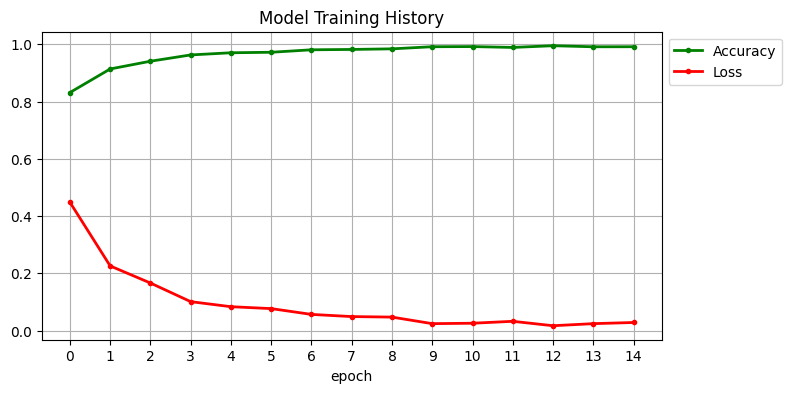

In [9]:
plt.figure(figsize=(8,4))
plt.grid(True)
plt.plot(history['sparse_categorical_accuracy'],'.g-', linewidth=2)
plt.plot(history['loss'], '.r-', linewidth=2)
plt.title('Model Training History')
plt.xlabel('epoch')
plt.xticks([x for x in range(15)]) #actualy for i in range(epochs) should be there, but after training the model, and loading the saved model, we can now use the number of epochs we trained
plt.legend(['Accuracy', 'Loss'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

## Model Classification Report

In [10]:

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
from sklearn.preprocessing import label_binarize
from tensorflow.keras.models import load_model
import numpy as np
IMAGE_SIZE = 128
# 1. Prediction on test data
test_images = open_images(test_paths)  # Load and augment test images
test_labels_encoded = encode_label(test_labels)  # Encode the test labels

# Predict using the trained model
test_predictions = model.predict(test_images)

# 2. Classification Report
print("Classification Report:")
print(classification_report(test_labels_encoded, np.argmax(test_predictions, axis=1)))

41/41 [==============================] - 29s 114ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       300
           1       0.94      0.96      0.95       306
           2       0.99      1.00      1.00       405
           3       0.99      0.99      0.99       300

    accuracy                           0.97      1311
   macro avg       0.97      0.97      0.97      1311
weighted avg       0.97      0.97      0.97      1311



## Modelling Confusion Plot

Confusion Matrix:
[[281  18   0   1]
 [  9 293   3   1]
 [  0   0 405   0]
 [  1   2   0 297]]


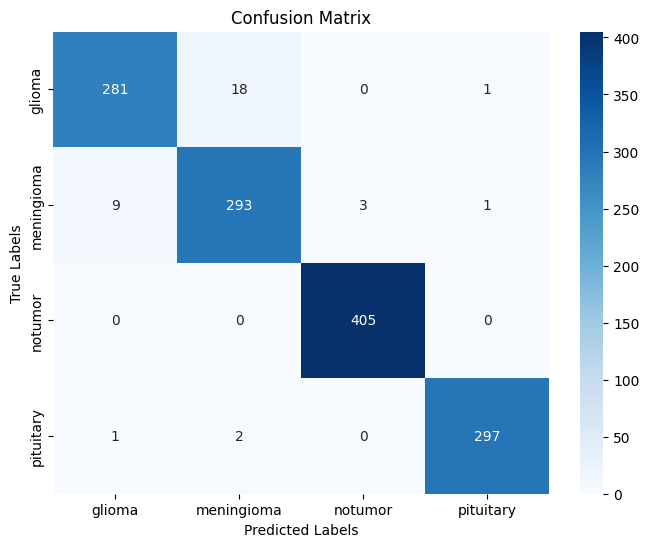

In [11]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(test_predictions, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

## Roc Curve Plot

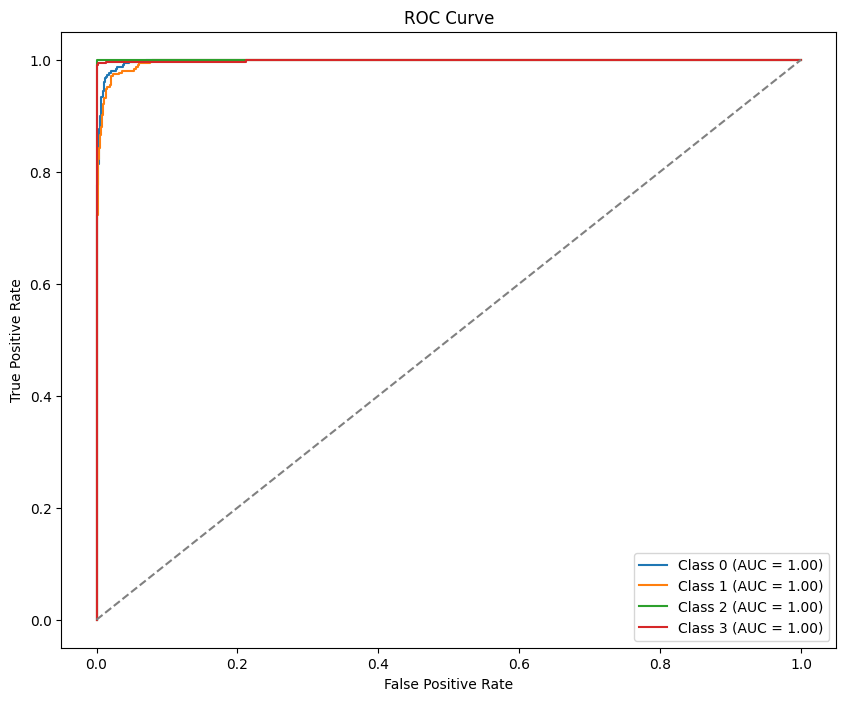

In [10]:
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = test_predictions  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## MRI Tumor Detection System (For new Images)

In [2]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = ['glioma', 'meninglioma', 'notumor', 'pituitary']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))


1/1 [==============================] - 6s 6s/step


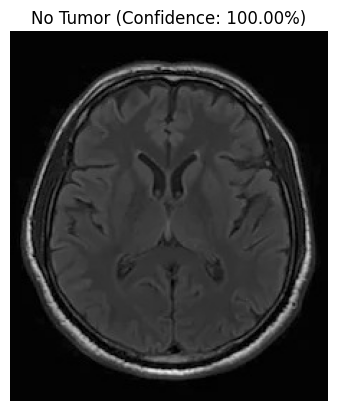

In [3]:
# Example usage
image_path = r"C:\Users\rajve\OneDrive\Desktop\all_programs\jupyter programs\Brain tumor prediction project\Testing\notumor\Te-no_0102.jpg"  # Provide the path to your new image
detect_and_display(image_path, model)


1/1 [==============================] - 0s 25ms/step


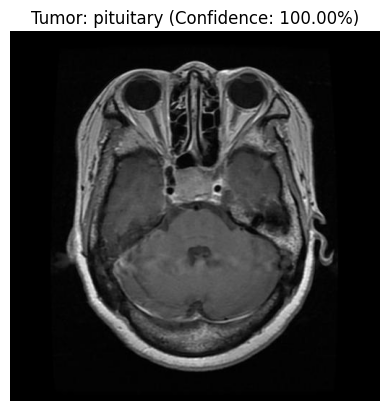

In [13]:
# Example usage
image_path = r"C:\Users\rajve\OneDrive\Desktop\all_programs\jupyter programs\Brain tumor prediction project\Testing\pituitary\Te-pi_0153.jpg"  # Provide the path to your new image
detect_and_display(image_path, model)
